# **Customer Churn Prediction using Machine Learning**

# Dataset Loading

The Telco Customer Churn dataset is loaded and inspected to understand its structure, size, and available features.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


# Initial Data Exploration

The dataset is explored to understand the number of features, dataset dimensions, data types, missing values, and statistical summary.

In [8]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [9]:
df.shape

(7043, 33)

In [10]:
df['Country'].nunique()

1

In [12]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [13]:
df['City'].nunique()

1129

In [14]:
df['State'].nunique()

1

In [15]:
df.describe().round(2)

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,1.0,93521.96,36.28,-119.80,32.37,64.76,0.27,58.70,4400.30
std,0.0,1865.79,2.46,2.16,24.56,30.09,0.44,21.53,1183.06
min,1.0,90001.00,32.56,-124.30,0.00,18.25,0.00,5.00,2003.00
25%,1.0,92102.00,34.03,-121.82,9.00,35.50,0.00,40.00,3469.00
50%,1.0,93552.00,36.39,-119.73,29.00,70.35,0.00,61.00,4527.00
75%,1.0,95351.00,38.22,-118.04,55.00,89.85,1.00,75.00,5380.50
max,1.0,96161.00,41.96,-114.19,72.00,118.75,1.00,100.00,6500.00


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

# Data Cleaning

This section handles missing values, converts incorrect data types, removes invalid records, and eliminates unnecessary columns such as identifiers and leakage features.

In [17]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
blank_tc = df['Total Charges'].isna().sum()
print(f'Blank Total Charges rows: {blank_tc}')
df.dropna(subset=['Total Charges'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after fix: {len(df):,}')

Blank Total Charges rows: 11
Rows after fix: 7,032


In [18]:
drop_cols = ['CustomerID', 'Count', 'Lat Long', 'Churn Score', 'Churn Reason','State','Country']
df.drop(columns=drop_cols, inplace=True)
print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')

Remaining columns (26): ['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'CLTV']


In [19]:
churn_counts = df['Churn Label'].value_counts()
churn_pct    = df['Churn Label'].value_counts(normalize=True) * 100
print('Target — Churn Label:')
print(f"  No  (stayed):  {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Yes (churned): {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")
print(f"\n⚠  Class imbalance: {churn_pct['Yes']:.0f}% churn rate")

Target — Churn Label:
  No  (stayed):  5,163  (73.4%)
  Yes (churned): 1,869  (26.6%)

⚠  Class imbalance: 27% churn rate


In [21]:
print(df.dtypes)

City                  object
Zip Code               int64
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
CLTV                   int64
dtype: object


In [22]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns")
print(cat_cols)

print("\nNumerical Columns")
print(num_cols)

Categorical Columns
Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Churn Label'],
      dtype='object')

Numerical Columns
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'CLTV'],
      dtype='object')


In [23]:
df.isnull().sum()

,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0


# Target Variable Analysis

The distribution of the target variable is analyzed to understand whether the dataset is balanced or imbalanced.

In [24]:
df["Churn Label"] = df["Churn Label"].map({
    "No":0,
    "Yes":1
})

In [25]:
df["Churn Label"].value_counts()

,count
Churn Label,
0,5163
1,1869


In [27]:
df.nunique().sort_values(ascending=False)

,0
Total Charges,6530
CLTV,3435
Zip Code,1652
Latitude,1652
Longitude,1651
Monthly Charges,1584
City,1129
Tenure Months,72
Payment Method,4
Multiple Lines,3


# Correlation Analysis

Correlation among numerical variables is analyzed to detect multicollinearity and understand relationships between features.

In [28]:
df[["Monthly Charges", "Tenure Months", "Total Charges"]].corr()

,Monthly Charges,Tenure Months,Total Charges
Monthly Charges,1.000000,0.246862,0.651065
Tenure Months,0.246862,1.000000,0.825880
Total Charges,0.651065,0.825880,1.000000


In [29]:
df["CLTV"].describe()

,CLTV
count,7032.000000
mean,4401.445108
std,1182.414266
min,2003.000000
25%,3469.750000
50%,4527.500000
75%,5381.000000
max,6500.000000


<Figure size 800x500 with 0 Axes>

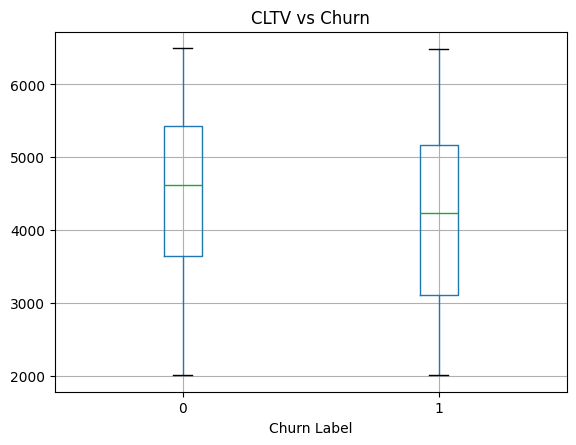

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.boxplot(column="CLTV", by="Churn Label")

plt.title("CLTV vs Churn")
plt.suptitle("")
plt.show()

In [31]:
df.groupby("Churn Label")["CLTV"].mean()

,CLTV
Churn Label,
0,4492.679837
1,4149.414660


In [32]:
df["Zip Code"].value_counts().head(20)

,count
Zip Code,
92284,5
92275,5
92268,5
90710,5
90704,5
90660,5
90631,5
90606,5
90602,5


In [33]:
pd.crosstab(
    df["Zip Code"],
    df["Churn Label"],
    normalize="index"
)

Churn Label,0,1
Zip Code,,
90001,0.60,0.40
90002,0.80,0.20
90003,0.80,0.20
90004,0.60,0.40
90005,0.40,0.60
...,...,...
96145,0.75,0.25
96146,1.00,0.00
96148,0.50,0.50


In [34]:
df.drop(columns=["Zip Code"], inplace=True)

In [35]:
df["City"].value_counts().head(20)

,count
City,
Los Angeles,304
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
Fresno,64
Long Beach,60
Oakland,52
Stockton,44


In [36]:
city_churn = pd.crosstab(
    df["City"],
    df["Churn Label"],
    normalize="index"
) * 100

city_churn

Churn Label,0,1
City,,
Acampo,25.0,75.0
Acton,100.0,0.0
Adelanto,80.0,20.0
Adin,50.0,50.0
Agoura Hills,60.0,40.0
...,...,...
Yreka,100.0,0.0
Yuba City,75.0,25.0
Yucaipa,75.0,25.0


In [37]:
city_churn.sort_values(1, ascending=False)

Churn Label,0,1
City,,
Wrightwood,0.0,100.0
Tipton,0.0,100.0
Truckee,0.0,100.0
Twain,0.0,100.0
Johannesburg,0.0,100.0
...,...,...
La Crescenta,100.0,0.0
San Miguel,100.0,0.0
Montara,100.0,0.0


In [38]:
top20 = df["City"].value_counts().nlargest(20).index

df["City"] = df["City"].where(
    df["City"].isin(top20),
    "Other"
)

In [39]:
df[["Latitude", "Longitude"]].describe()

,Latitude,Longitude
count,7032.000000,7032.000000
mean,36.283307,-119.799215
std,2.456118,2.157588
min,32.555828,-124.301372
25%,34.030915,-121.815412
50%,36.391777,-119.735410
75%,38.227285,-118.043237
max,41.962127,-114.192901


In [40]:
df.groupby("Churn Label")[["Latitude", "Longitude"]].mean()

,Latitude,Longitude
Churn Label,,
0,36.288626,-119.805307
1,36.268614,-119.782388


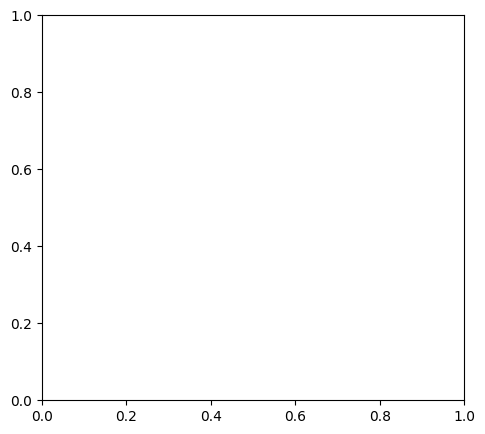

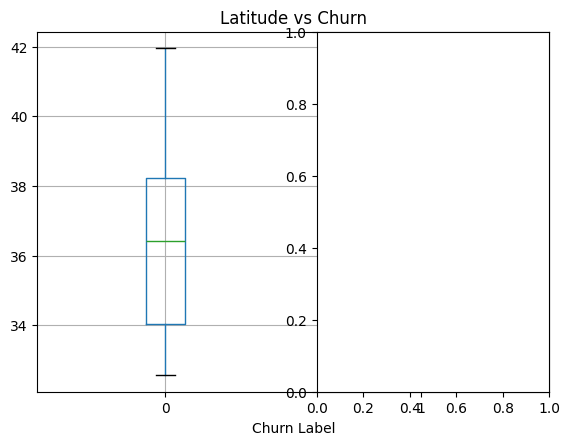

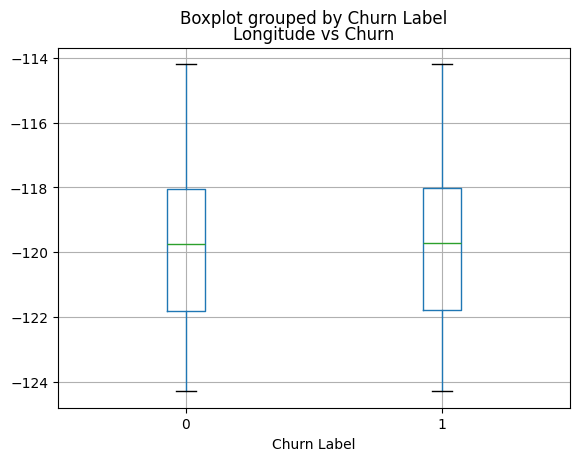

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df.boxplot(column="Latitude", by="Churn Label")
plt.title("Latitude vs Churn")
plt.suptitle("")

plt.subplot(1,2,2)
df.boxplot(column="Longitude", by="Churn Label")
plt.title("Longitude vs Churn")

plt.show()

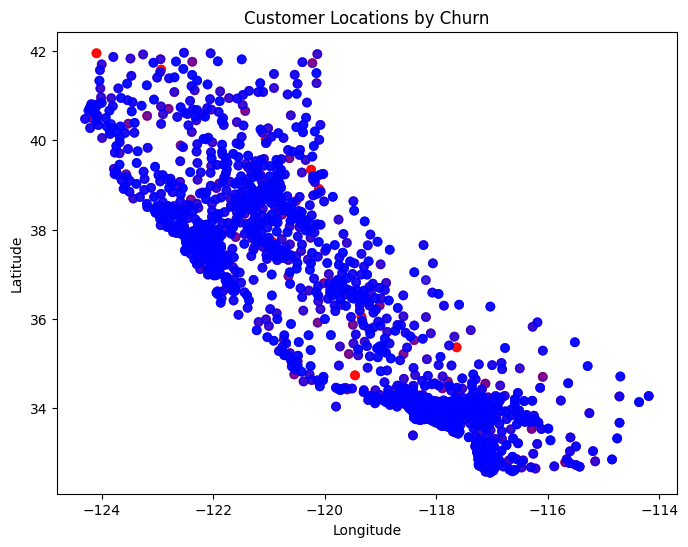

In [42]:
plt.figure(figsize=(8,6))

colors = df["Churn Label"].map({0:"blue", 1:"red"})

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=colors,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Customer Locations by Churn")

plt.show()

In [43]:
df[["Latitude","Longitude","Churn Label"]].corr()

,Latitude,Longitude,Churn Label
Latitude,1.000000,-0.876777,-0.003600
Longitude,-0.876777,1.000000,0.004693
Churn Label,-0.003600,0.004693,1.000000


In [44]:
df.drop(columns=["Latitude", "Longitude"], inplace=True)

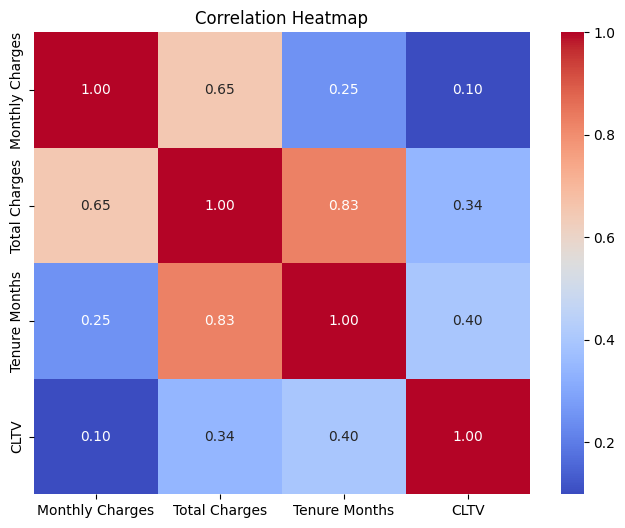

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "Monthly Charges",
        "Total Charges",
        "Tenure Months",
        "CLTV"
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [47]:
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include="object").columns

results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["Churn Label"])
    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Feature": col,
        "P-Value": p,
        "Significant": p < 0.05
    })

chi_results = (
    pd.DataFrame(results)
      .sort_values("P-Value")
)

print(chi_results)

              Feature        P-Value  Significant
14           Contract  7.326182e-257         True
8     Online Security  1.400687e-184         True
11       Tech Support  7.407808e-180         True
7    Internet Service  5.831199e-159         True
16     Payment Method  1.426310e-139         True
9       Online Backup  7.776099e-131         True
10  Device Protection  1.959389e-121         True
4          Dependents   7.098585e-96         True
13   Streaming Movies   5.353560e-82         True
12       Streaming TV   1.324641e-81         True
15  Paperless Billing   8.236203e-58         True
2      Senior Citizen   2.479256e-36         True
3             Partner   3.973798e-36         True
6      Multiple Lines   3.567927e-03         True
0                City   3.141539e-01        False
5       Phone Service   3.499240e-01        False
1              Gender   4.904885e-01        False


In [48]:
drop_cols = ["Gender", "Phone Service"]

df.drop(columns=drop_cols, inplace=True)

print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 21


In [49]:
df.columns

Index(['City', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'CLTV'],
      dtype='object')

In [50]:
df.drop(columns=["Churn Label"], inplace=True)

print(df.columns.tolist())

['City', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


# Feature Engineering and Feature Selection

Feature selection decisions were based on domain knowledge, correlation analysis, Chi-Square statistical testing, and model experiments. Three different feature sets were created to evaluate the impact of removing City and CLTV on model performance.

In [52]:
df_all = df.copy()

X_all = df_all.drop(columns=["Churn Value"])
y_all = df_all["Churn Value"]

In [53]:
df_no_city = df.drop(columns=["City"]).copy()

X_no_city = df_no_city.drop(columns=["Churn Value"])
y_no_city = df_no_city["Churn Value"]

In [54]:
df_no_city_cltv = df.drop(columns=["City", "CLTV"]).copy()

X_no_city_cltv = df_no_city_cltv.drop(columns=["Churn Value"])
y_no_city_cltv = df_no_city_cltv["Churn Value"]

In [55]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

X_all_encoded = X_all.copy()

binary_cols = [
    col for col in X_all_encoded.columns
    if X_all_encoded[col].dtype == "object"
    and X_all_encoded[col].nunique() == 2
]

multi_cols = [
    col for col in X_all_encoded.columns
    if X_all_encoded[col].dtype == "object"
    and X_all_encoded[col].nunique() > 2
]

le = LabelEncoder()

for col in binary_cols:
    X_all_encoded[col] = le.fit_transform(X_all_encoded[col])

X_all_encoded = pd.get_dummies(
    X_all_encoded,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

print(X_all_encoded.shape)

(7032, 49)


In [56]:
X_no_city_encoded = X_no_city.copy()

binary_cols = [
    col for col in X_no_city_encoded.columns
    if X_no_city_encoded[col].dtype == "object"
    and X_no_city_encoded[col].nunique() == 2
]

multi_cols = [
    col for col in X_no_city_encoded.columns
    if X_no_city_encoded[col].dtype == "object"
    and X_no_city_encoded[col].nunique() > 2
]

le = LabelEncoder()

for col in binary_cols:
    X_no_city_encoded[col] = le.fit_transform(X_no_city_encoded[col])

X_no_city_encoded = pd.get_dummies(
    X_no_city_encoded,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

print(X_no_city_encoded.shape)

(7032, 29)


In [57]:
X_no_city_cltv_encoded = X_no_city_cltv.copy()

binary_cols = [
    col for col in X_no_city_cltv_encoded.columns
    if X_no_city_cltv_encoded[col].dtype == "object"
    and X_no_city_cltv_encoded[col].nunique() == 2
]

multi_cols = [
    col for col in X_no_city_cltv_encoded.columns
    if X_no_city_cltv_encoded[col].dtype == "object"
    and X_no_city_cltv_encoded[col].nunique() > 2
]

le = LabelEncoder()

for col in binary_cols:
    X_no_city_cltv_encoded[col] = le.fit_transform(X_no_city_cltv_encoded[col])

X_no_city_cltv_encoded = pd.get_dummies(
    X_no_city_cltv_encoded,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

print(X_no_city_cltv_encoded.shape)

(7032, 28)


# Model Development

The dataset was encoded, split into training and testing sets, and scaled where required. Five classification algorithms were trained and compared to identify the most suitable model for predicting customer churn.

In [58]:
from sklearn.model_selection import train_test_split

# Dataset 1
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_encoded,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Dataset 2
X_train_no_city, X_test_no_city, y_train_no_city, y_test_no_city = train_test_split(
    X_no_city_encoded,
    y_no_city,
    test_size=0.2,
    random_state=42,
    stratify=y_no_city
)

# Dataset 3
X_train_no_city_cltv, X_test_no_city_cltv, y_train_no_city_cltv, y_test_no_city_cltv = train_test_split(
    X_no_city_cltv_encoded,
    y_no_city_cltv,
    test_size=0.2,
    random_state=42,
    stratify=y_no_city_cltv
)

#Model Creation


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [61]:
from sklearn.preprocessing import StandardScaler

# Dataset 1
scaler_all = StandardScaler()

X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

# Dataset 2
scaler_no_city = StandardScaler()

X_train_no_city_scaled = scaler_no_city.fit_transform(X_train_no_city)
X_test_no_city_scaled = scaler_no_city.transform(X_test_no_city)

# Dataset 3
scaler_no_city_cltv = StandardScaler()

X_train_no_city_cltv_scaled = scaler_no_city_cltv.fit_transform(X_train_no_city_cltv)
X_test_no_city_cltv_scaled = scaler_no_city_cltv.transform(X_test_no_city_cltv)

In [62]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42, probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [63]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [64]:
results = []

def evaluate_model(
    model,
    model_name,
    dataset_name,
    X_train,
    X_test,
    y_train,
    y_test
):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    # Store metrics
    results.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

    print("="*60)
    print(f"{model_name} | {dataset_name}")
    print("="*60)

    print("\nAccuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

In [65]:
for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:

        evaluate_model(
            model,
            name,
            "All Features",
            X_train_all_scaled,
            X_test_all_scaled,
            y_train_all,
            y_test_all
        )

    else:

        evaluate_model(
            model,
            name,
            "All Features",
            X_train_all,
            X_test_all,
            y_train_all,
            y_test_all
        )

Logistic Regression | All Features

Accuracy : 0.8052594171997157
Precision: 0.6436781609195402
Recall   : 0.5989304812834224
F1 Score : 0.6204986149584487
ROC AUC  : 0.8407576706648513

Confusion Matrix
[[909 124]
 [150 224]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.74      1407
weighted avg       0.80      0.81      0.80      1407

Decision Tree | All Features

Accuracy : 0.7448471926083866
Precision: 0.5196850393700787
Recall   : 0.5294117647058824
F1 Score : 0.5245033112582781
ROC AUC  : 0.6761289220431638

Confusion Matrix
[[850 183]
 [176 198]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1033
           1       0.52      0.53      0.52       374

    accuracy   

In [66]:
for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:

        evaluate_model(
            model,
            name,
            "Without City",
            X_train_no_city_scaled,
            X_test_no_city_scaled,
            y_train_no_city,
            y_test_no_city
        )

    else:

        evaluate_model(
            model,
            name,
            "Without City",
            X_train_no_city,
            X_test_no_city,
            y_train_no_city,
            y_test_no_city
        )

Logistic Regression | Without City

Accuracy : 0.8052594171997157
Precision: 0.6420454545454546
Recall   : 0.6042780748663101
F1 Score : 0.6225895316804407
ROC AUC  : 0.8428775540842052

Confusion Matrix
[[907 126]
 [148 226]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407

Decision Tree | Without City

Accuracy : 0.738450604122246
Precision: 0.5080645161290323
Recall   : 0.5053475935828877
F1 Score : 0.5067024128686327
ROC AUC  : 0.6640968364816665

Confusion Matrix
[[850 183]
 [185 189]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.51      0.51      0.51       374

    accuracy    

In [67]:
for name, model in models.items():

    if name in ["Logistic Regression", "SVM"]:

        evaluate_model(
            model,
            name,
            "Without City & CLTV",
            X_train_no_city_cltv_scaled,
            X_test_no_city_cltv_scaled,
            y_train_no_city_cltv,
            y_test_no_city_cltv
        )

    else:

        evaluate_model(
            model,
            name,
            "Without City & CLTV",
            X_train_no_city_cltv,
            X_test_no_city_cltv,
            y_train_no_city_cltv,
            y_test_no_city_cltv
        )

Logistic Regression | Without City & CLTV

Accuracy : 0.8052594171997157
Precision: 0.6428571428571429
Recall   : 0.6016042780748663
F1 Score : 0.6215469613259669
ROC AUC  : 0.8428490819015276

Confusion Matrix
[[908 125]
 [149 225]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1033
           1       0.64      0.60      0.62       374

    accuracy                           0.81      1407
   macro avg       0.75      0.74      0.75      1407
weighted avg       0.80      0.81      0.80      1407

Decision Tree | Without City & CLTV

Accuracy : 0.7242359630419332
Precision: 0.4808743169398907
Recall   : 0.47058823529411764
F1 Score : 0.4756756756756757
ROC AUC  : 0.6436525151290824

Confusion Matrix
[[843 190]
 [198 176]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1033
           1       0.48      0.47      0.48       374



In [68]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,Without City,Logistic Regression,0.805259,0.642045,0.604278,0.622590,0.842878
10,Without City & CLTV,Logistic Regression,0.805259,0.642857,0.601604,0.621547,0.842849
0,All Features,Logistic Regression,0.805259,0.643678,0.598930,0.620499,0.840758
9,Without City,Gradient Boosting,0.797441,0.640379,0.542781,0.587554,0.847102
14,Without City & CLTV,Gradient Boosting,0.793888,0.629630,0.545455,0.584527,0.847066
13,Without City & CLTV,SVM,0.795309,0.636076,0.537433,0.582609,0.802965
4,All Features,Gradient Boosting,0.793888,0.632911,0.534759,0.579710,0.846745
8,Without City,SVM,0.794598,0.635783,0.532086,0.579330,0.805452
2,All Features,Random Forest,0.789623,0.627451,0.513369,0.564706,0.833751
3,All Features,SVM,0.789623,0.629139,0.508021,0.562130,0.816881


# Model Evaluation and Hyperparameter Tuning

Models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Cross-validation was used to assess model stability, and GridSearchCV was applied to optimize the hyperparameters of the best-performing models.

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

cv_scores = cross_val_score(
    lr,
    X_train_no_city_cltv_scaled,
    y_train_no_city_cltv,
    cv=5,
    scoring="f1"
)

print("Fold Scores:", cv_scores)
print("Average F1:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Fold Scores: [0.60915493 0.63752277 0.609319   0.58657244 0.62587413]
Average F1: 0.613688651740043
Standard Deviation: 0.01727129684070629


In [70]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

cv_scores = cross_val_score(
    gb,
    X_train_no_city_cltv,
    y_train_no_city_cltv,
    cv=5,
    scoring="f1"
)

print("Fold Scores:", cv_scores)
print("Average F1:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Fold Scores: [0.59016393 0.61132075 0.6007326  0.57301294 0.6       ]
Average F1: 0.595046045775532
Standard Deviation: 0.012892148976755564


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_no_city_cltv_scaled, y_train_no_city_cltv)

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest CV F1:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV F1:
0.6387175745366733


In [75]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_gb.fit(X_train_no_city_cltv, y_train_no_city_cltv)

print("Best Parameters:")
print(grid_gb.best_params_)

print("\nBest CV F1:")
print(grid_gb.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

Best CV F1:
0.6062183385602044


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

best_lr = grid_lr.best_estimator_

y_pred = best_lr.predict(X_test_no_city_cltv_scaled)
y_prob = best_lr.predict_proba(X_test_no_city_cltv_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test_no_city_cltv, y_pred))
print("Precision:", precision_score(y_test_no_city_cltv, y_pred))
print("Recall   :", recall_score(y_test_no_city_cltv, y_pred))
print("F1 Score :", f1_score(y_test_no_city_cltv, y_pred))
print("ROC AUC  :", roc_auc_score(y_test_no_city_cltv, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_no_city_cltv, y_pred))

print("\nClassification Report")
print(classification_report(y_test_no_city_cltv, y_pred))

Accuracy : 0.7974413646055437
Precision: 0.6032482598607889
Recall   : 0.6951871657754011
F1 Score : 0.6459627329192547
ROC AUC  : 0.838433305206268

Confusion Matrix
[[862 171]
 [114 260]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      1033
           1       0.60      0.70      0.65       374

    accuracy                           0.80      1407
   macro avg       0.74      0.76      0.75      1407
weighted avg       0.81      0.80      0.80      1407



In [77]:
best_gb = grid_gb.best_estimator_

y_pred = best_gb.predict(X_test_no_city_cltv)
y_prob = best_gb.predict_proba(X_test_no_city_cltv)[:, 1]

print("Accuracy :", accuracy_score(y_test_no_city_cltv, y_pred))
print("Precision:", precision_score(y_test_no_city_cltv, y_pred))
print("Recall   :", recall_score(y_test_no_city_cltv, y_pred))
print("F1 Score :", f1_score(y_test_no_city_cltv, y_pred))
print("ROC AUC  :", roc_auc_score(y_test_no_city_cltv, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_no_city_cltv, y_pred))

print("\nClassification Report")
print(classification_report(y_test_no_city_cltv, y_pred))

Accuracy : 0.7924662402274343
Precision: 0.625
Recall   : 0.5481283422459893
F1 Score : 0.584045584045584
ROC AUC  : 0.8456186487619778

Confusion Matrix
[[910 123]
 [169 205]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



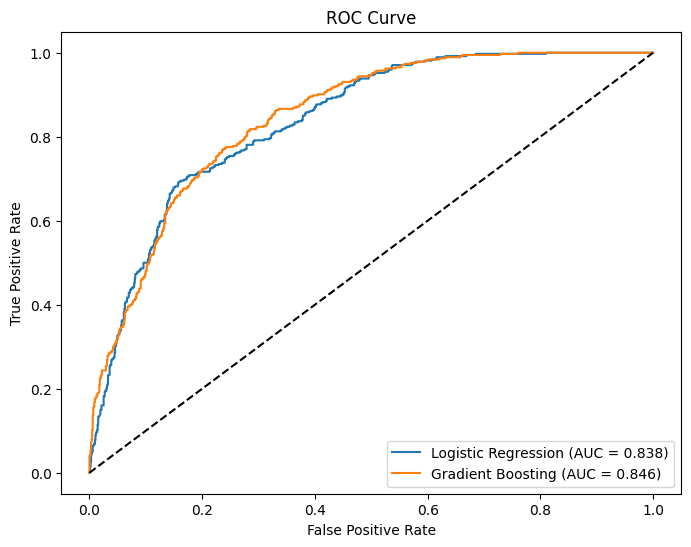

In [78]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression
lr_prob = best_lr.predict_proba(X_test_no_city_cltv_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_no_city_cltv, lr_prob)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Gradient Boosting
gb_prob = best_gb.predict_proba(X_test_no_city_cltv)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test_no_city_cltv, gb_prob)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")

plt.plot(fpr_gb, tpr_gb,
         label=f"Gradient Boosting (AUC = {roc_auc_gb:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

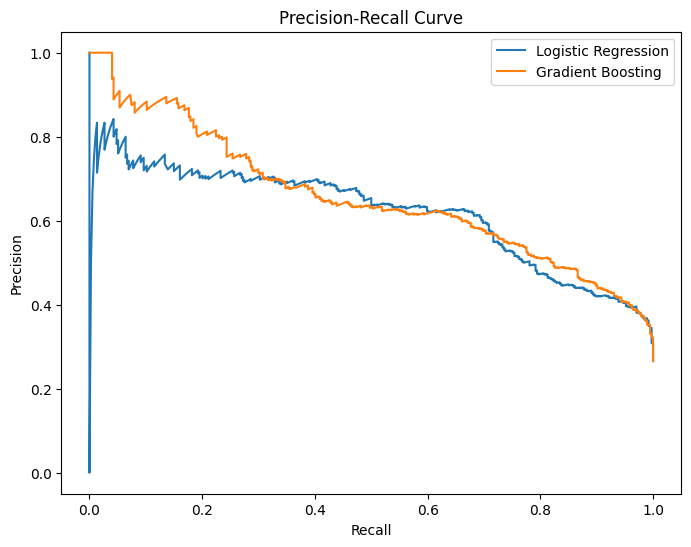

In [79]:
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test_no_city_cltv,
    lr_prob
)

precision_gb, recall_gb, _ = precision_recall_curve(
    y_test_no_city_cltv,
    gb_prob
)

plt.figure(figsize=(8,6))

plt.plot(recall_lr, precision_lr,
         label="Logistic Regression")

plt.plot(recall_gb, precision_gb,
         label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

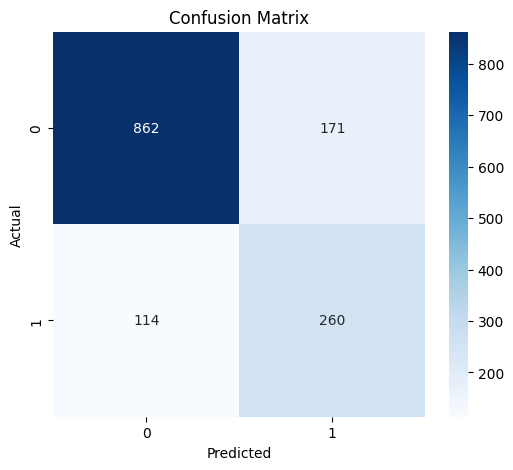

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test_no_city_cltv,
    best_lr.predict(X_test_no_city_cltv_scaled)
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [81]:
coef_df = pd.DataFrame({
    "Feature": X_train_no_city_cltv.columns,
    "Coefficient": best_lr.coef_[0]
})

coef_df["Absolute"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Absolute
3,Tenure Months,-0.220948,0.220948
2,Dependents,-0.185391,0.185391
9,Internet Service_Fiber optic,0.169771,0.169771
6,Total Charges,-0.147193,0.147193
24,Contract_Two year,-0.142389,0.142389
23,Contract_One year,-0.137502,0.137502
26,Payment Method_Electronic check,0.128952,0.128952
12,Online Security_Yes,-0.119005,0.119005
18,Tech Support_Yes,-0.112551,0.112551
4,Paperless Billing,0.080105,0.080105


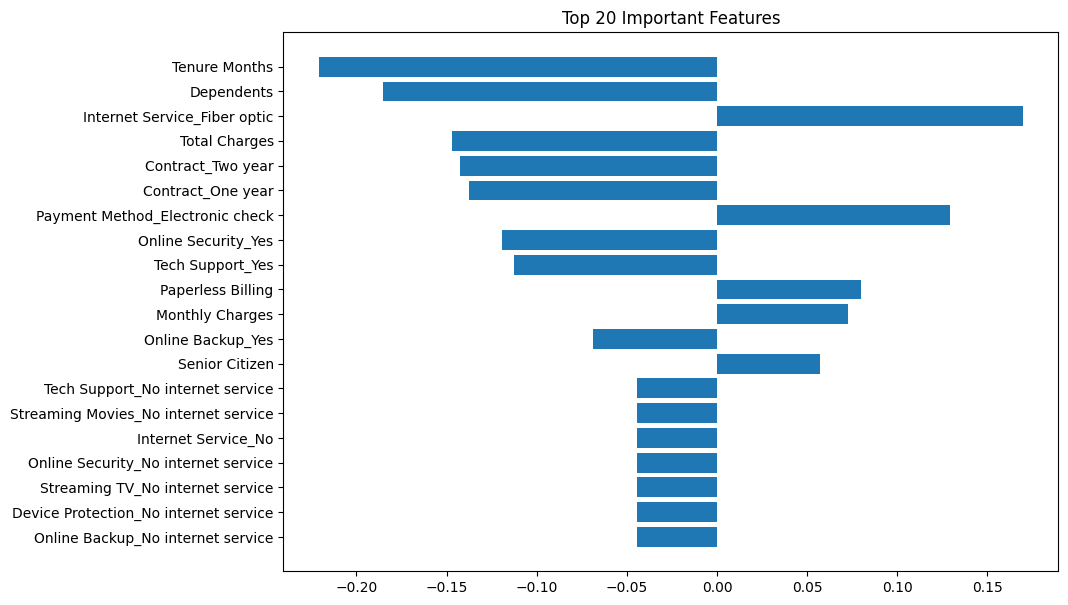

In [82]:
top20 = coef_df.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Feature"],
    top20["Coefficient"]
)

plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Conclusion

Among all evaluated models, the tuned Logistic Regression model achieved the best balance between Precision and Recall, resulting in the highest F1-score. Although Gradient Boosting achieved a slightly higher ROC-AUC, Logistic Regression was selected as the final model because customer churn prediction prioritizes identifying customers likely to leave while maintaining balanced performance.

In [83]:
import joblib

joblib.dump(best_lr,"telco_churn_model.pkl")
joblib.dump(scaler_no_city_cltv,"scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
